# Useful Packages, Constants, and Routines

In [33]:
!pip install -Uq pymcel rebound
import pymcel as pc
import rebound as rb
import matplotlib.pyplot as plt
import plotly.io as pio
import numpy as np
import pickle
import math
from numba import njit

deg = np.pi / 180
rad = 1 / deg

Non-spherical potential model:

In [34]:
# Routines for calculating the acceleration due to the non-spherical potential
# EGM96 model parameters
GM_DEFAULT = 398600.4415e9  # m^3/s^2
A_DEFAULT = 6378136.3       # m

def prepare_workspace(Nmax):
    ms = np.arange(Nmax+1, dtype=np.int32)
    exps = np.arange(Nmax+1, dtype=np.int32)
    P = np.zeros((Nmax+1, Nmax+1), dtype=np.float64)
    dP_dx = np.zeros_like(P)
    cos_mth = np.zeros(Nmax+1, dtype=np.float64)
    sin_mth = np.zeros(Nmax+1, dtype=np.float64)
    rn = np.zeros(Nmax+1, dtype=np.float64)
    temp1 = np.zeros(Nmax+1, dtype=np.float64)
    temp2 = np.zeros(Nmax+1, dtype=np.float64)
    return {
        'Nmax': Nmax,
        'ms': ms,
        'exps': exps,
        'P': P,
        'dP_dx': dP_dx,
        'cos_mth': cos_mth,
        'sin_mth': sin_mth,
        'rn': rn,
        'temp1': temp1,
        'temp2': temp2
    }

@njit
def _compute_P_and_derivatives_rec_jit(Nmax, x, P, dP_dx):
    if x > 1.0:
        x = 1.0
    if x < -1.0:
        x = -1.0
    one_minus_x2 = 1.0 - x*x
    if one_minus_x2 < 0.0:
        one_minus_x2 = 0.0
    P[0, 0] = 1.0
    if Nmax >= 1:
        P[1, 0] = x
        if one_minus_x2 > 0.0:
            P[1, 1] = -math.sqrt(one_minus_x2)
        else:
            P[1, 1] = 0.0
    for m in range(2, Nmax+1):
        if one_minus_x2 <= 0.0:
            P[m, m] = 0.0
        else:
            df = 1.0
            for k in range(1, m+1):
                df *= (2*k - 1)
            P[m, m] = ((-1.0)**m) * df * (one_minus_x2 ** (0.5*m))
        if m < Nmax:
            P[m+1, m] = x * (2*m + 1) * P[m, m]
    for m in range(0, Nmax+1):
        start = 2 if m == 0 else m+1
        for n in range(start, Nmax+1):
            P[n, m] = ((2*n - 1) * x * P[n-1, m] - (n + m - 1) * P[n-2, m]) / (n - m)
    denom = one_minus_x2 if one_minus_x2 >= 1e-16 else 1e-16
    for n in range(1, Nmax+1):
        for m in range(0, n+1):
            dP_dx[n, m] = ((n + m) * P[n-1, m] - n * x * P[n, m]) / denom

@njit
def gravity_anomalous_ecef_fast_jit(x_ecef, y_ecef, z_ecef, C, S, P, dP_dx, ms, exps, cos_mth, sin_mth, rn, GM, a):
    r = math.sqrt(x_ecef*x_ecef + y_ecef*y_ecef + z_ecef*z_ecef)
    x = z_ecef / r
    if x > 1.0:
        x = 1.0
    if x < -1.0:
        x = -1.0
    cos_phi = x
    sin_phi = math.sqrt(max(0.0, 1.0 - x*x))
    theta = math.atan2(y_ecef, x_ecef)

    Nmax = P.shape[0] - 1
    _compute_P_and_derivatives_rec_jit(Nmax, x, P, dP_dx)

    for i in range(Nmax+1):
        cos_mth[i] = math.cos(i * theta)
        sin_mth[i] = math.sin(i * theta)

    for i in range(Nmax+1):
        rn[i] = (a / r) ** i

    S_total = 0.0
    Srad_weighted = 0.0

    dV_dphi_acc = 0.0
    dV_dtheta_acc = 0.0
    for n in range(0, Nmax+1):
        S_n_val = 0.0
        dSphi_n_val = 0.0
        dStheta_n_val = 0.0
        mmax = n
        for m in range(0, mmax+1):
            Pnm = P[n, m]
            dPphi = -sin_phi * dP_dx[n, m]
            Cnm = C[n, m]
            Snm = S[n, m]
            ang_cos = cos_mth[m]
            ang_sin = sin_mth[m]
            combo = Cnm * ang_cos + Snm * ang_sin
            S_n_val += Pnm * combo
            dSphi_n_val += dPphi * combo
            if m != 0:
                dStheta_n_val += Pnm * (-m * Cnm * ang_sin + m * Snm * ang_cos)
        if n >= 2:
            S_total += rn[n] * S_n_val
            Srad_weighted += n * rn[n] * S_n_val
            dV_dphi_acc += rn[n] * dSphi_n_val
            dV_dtheta_acc += rn[n] * dStheta_n_val

    dV_dr_anom = -GM / (r*r) * (S_total + Srad_weighted)
    dV_dphi = GM / r * dV_dphi_acc
    dV_dtheta = GM / r * dV_dtheta_acc

    er_x = sin_phi * math.cos(theta)
    er_y = sin_phi * math.sin(theta)
    er_z = cos_phi
    ephi_x = x * math.cos(theta)
    ephi_y = x * math.sin(theta)
    ephi_z = -sin_phi
    etheta_x = -math.sin(theta)
    etheta_y = math.cos(theta)
    etheta_z = 0.0

    inv_r = 1.0 / r
    inv_r_sinphi = 0.0 if abs(sin_phi) < 1e-12 else 1.0 / (r * sin_phi)
    gradV_anom_x = dV_dr_anom * er_x + inv_r * dV_dphi * ephi_x + inv_r_sinphi * dV_dtheta * etheta_x
    gradV_anom_y = dV_dr_anom * er_y + inv_r * dV_dphi * ephi_y + inv_r_sinphi * dV_dtheta * etheta_y
    gradV_anom_z = dV_dr_anom * er_z + inv_r * dV_dphi * ephi_z + inv_r_sinphi * dV_dtheta * etheta_z
    gx = +gradV_anom_x
    gy = +gradV_anom_y
    gz = +gradV_anom_z
    return gx, gy, gz

def gravity_anomalous_ecef_numba(pos, C, S, workspace, GM=GM_DEFAULT, a=A_DEFAULT):
    x_ecef, y_ecef, z_ecef = pos
    return gravity_anomalous_ecef_fast_jit(x_ecef, y_ecef, z_ecef,
                                            C, S,
                                            workspace['P'], workspace['dP_dx'],
                                            workspace['ms'], workspace['exps'],
                                            workspace['cos_mth'], workspace['sin_mth'],
                                            workspace['rn'], GM, a)

# Potential data
!gdown 1iNVBNS7yjlGgQec5mdD400pXwsfgWZVg

# Open the file
f = open('egm96_coeffs_unnorm.pkl', 'rb')
# Read the data
data = pickle.load(f)

# Load the unnormalized coefficients up to the desired degree
N = 6
C = data.get('C')[:N+1,:N+1]
S = data.get('S')[:N+1,:N+1]

# To simulate only the effect of J2
#C[2,1:]=0
#S[:, :]=0
workspace = prepare_workspace(N)

# Rebound routine
def aceleracion_no_esferico_full(simulacion):

  # Retrieve all simulation data
  sim = simulacion.contents

  # Get the particle
  p = sim.particles[1]

  # Calculate the anomalous acceleration
  px, py, pz = gravity_anomalous_ecef_numba(p.xyz, C, S, workspace)

  # Modify the particle acceleration
  p.ax += px
  p.ay += py
  p.az += pz

# Rebound routine
def aceleracion_no_esferico_J2(simulacion):

  # Retrieve all simulation data
  sim = simulacion.contents

  # Get the particle
  p = sim.particles[1]

  # Position
  x = p.x
  y = p.y
  z = p.z
  r_vec = np.array([x, y, z])
  r = np.linalg.norm(r_vec)

  # Components
  factor = -3 * C[2,0] * GM_DEFAULT * A_DEFAULT**2 / ( 2*r**4 )
  zr2 = z**2 / r**2
  px = factor * (x/r) * (5*zr2 - 1)
  py = factor * (y/r) * (5*zr2 - 1)
  pz = factor * (z/r) * (5*zr2 - 3)

  p.ax += px
  p.ay += py
  p.az += pz

Using cookies from C:\Users\User\.cache/gdown/cookies.txt
Downloading...
From: https://drive.google.com/uc?id=1iNVBNS7yjlGgQec5mdD400pXwsfgWZVg
To: c:\Users\User\OneDrive\Documentos\OTROS\Astrodynamics\NFR\egm96_coeffs_unnorm.pkl

  0%|          | 0.00/4.17M [00:00<?, ?B/s]
 13%|█▎        | 524k/4.17M [00:00<00:01, 3.47MB/s]
 38%|███▊      | 1.57M/4.17M [00:00<00:00, 5.96MB/s]
 75%|███████▌  | 3.15M/4.17M [00:00<00:00, 8.93MB/s]
100%|██████████| 4.17M/4.17M [00:00<00:00, 8.54MB/s]


Tests:

Only with J2:

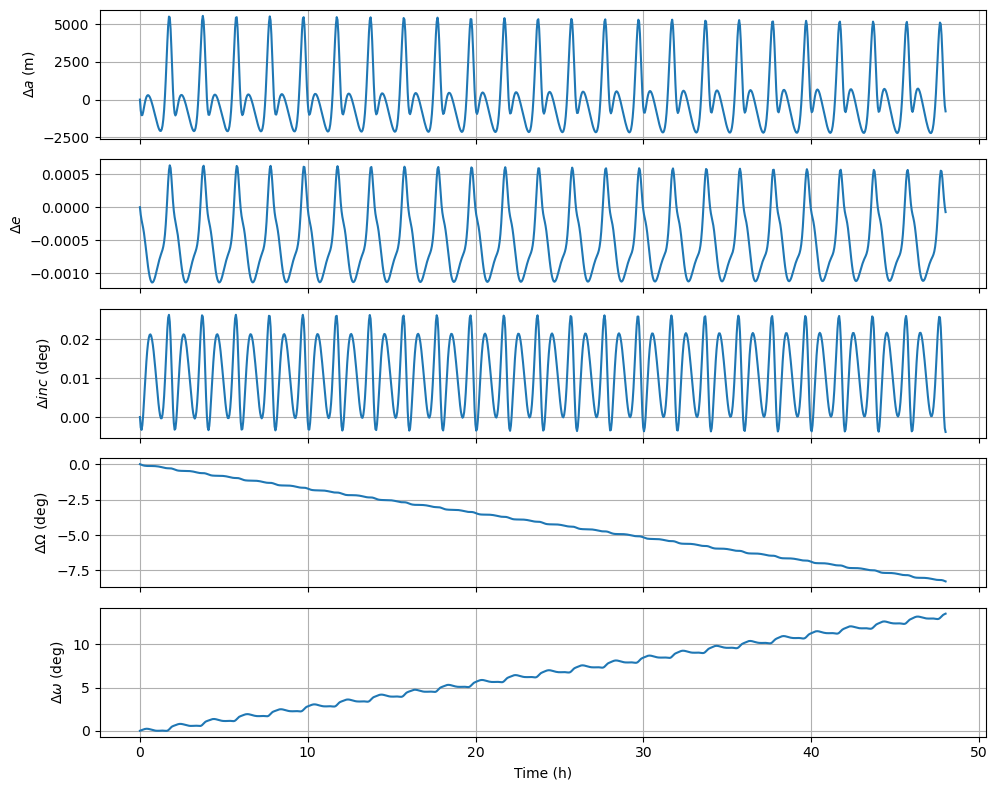

In [35]:
# Initial conditions
a_0 = 8059e3
e_0 = 0.17136
Omega_0 = 45*deg
inc_0 = 28*deg
omega_0 = 30*deg
f_0 = 40*deg
M = GM_DEFAULT / pc.constantes.G

# System creation
sim = rb.Simulation()
sim.units = 'kg', 'm', 's'
sim.add(m=M)
sim.add(m=0, a=a_0, e=e_0, inc=inc_0, Omega=Omega_0, omega=omega_0, f=f_0)

sim.additional_forces = aceleracion_no_esferico_J2
sim.force_is_velocity_dependent = True

# Simulation
deltat = 48*3600
Nt = 1000
ts = np.linspace(sim.t, sim.t + deltat, Nt)
Es = np.zeros((Nt, 5))

for i, t_step in enumerate(ts):
    sim.integrate(t_step)
    o = sim.orbits()[0]
    Es[i] = [o.a, o.e, o.inc, o.Omega, o.omega]

# Plotting
pio.renderers.default = "png"
fig, axes = plt.subplots(5, 1, sharex=True, figsize=(10, 8))

# Difference in a
axes[0].plot(ts/3600, Es[:, 0] - a_0)
axes[0].set_ylabel(r'$\Delta a$ (m)')
axes[0].grid(True)

# Difference in e
axes[1].plot(ts/3600, Es[:, 1] - e_0)
axes[1].set_ylabel(r'$\Delta e$')
axes[1].grid(True)

# Difference in inclination in degrees
axes[2].plot(ts/3600, (Es[:, 2] - inc_0) * rad)
axes[2].set_ylabel(r'$\Delta inc$ (deg)')
axes[2].grid(True)

# Difference in Omega in degrees
axes[3].plot(ts/3600, (Es[:, 3] - Omega_0) * rad)
axes[3].set_ylabel(r'$\Delta \Omega$ (deg)')
axes[3].grid(True)

# Difference in omega in degrees
axes[4].plot(ts/3600, (Es[:, 4] - omega_0) * rad)
axes[4].set_ylabel(r'$\Delta \omega$ (deg)')
axes[4].set_xlabel('Time (h)')
axes[4].grid(True)

plt.tight_layout()
plt.show()

With all harmonics:

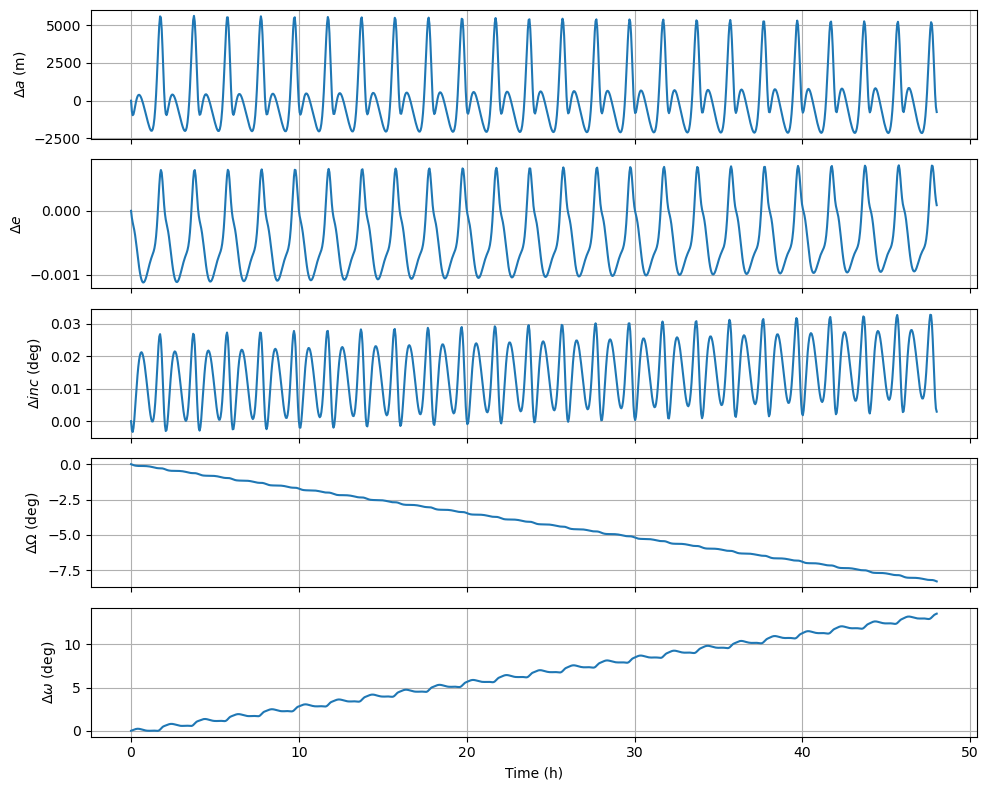

In [36]:
# Initial conditions
a_0 = 8059e3
e_0 = 0.17136
Omega_0 = 45*deg
inc_0 = 28*deg
omega_0 = 30*deg
f_0 = 40*deg
M = GM_DEFAULT / pc.constantes.G

# System creation
sim = rb.Simulation()
sim.units = 'kg', 'm', 's'
sim.add(m=M)
sim.add(m=0, a=a_0, e=e_0, inc=inc_0, Omega=Omega_0, omega=omega_0, f=f_0)

sim.additional_forces = aceleracion_no_esferico_full
sim.force_is_velocity_dependent = True

# Simulation
deltat = 48*3600
Nt = 1000
ts = np.linspace(sim.t, sim.t + deltat, Nt)
Es = np.zeros((Nt, 5))

for i, t_step in enumerate(ts):
    sim.integrate(t_step)
    o = sim.orbits()[0]
    Es[i] = [o.a, o.e, o.inc, o.Omega, o.omega]

# Plotting
pio.renderers.default = "png"
fig, axes = plt.subplots(5, 1, sharex=True, figsize=(10, 8))

# Difference in a
axes[0].plot(ts/3600, Es[:, 0] - a_0)
axes[0].set_ylabel(r'$\Delta a$ (m)')
axes[0].grid(True)

# Difference in e
axes[1].plot(ts/3600, Es[:, 1] - e_0)
axes[1].set_ylabel(r'$\Delta e$')
axes[1].grid(True)

# Difference in inclination in degrees
axes[2].plot(ts/3600, (Es[:, 2] - inc_0) * rad)
axes[2].set_ylabel(r'$\Delta inc$ (deg)')
axes[2].grid(True)

# Difference in Omega in degrees
axes[3].plot(ts/3600, (Es[:, 3] - Omega_0) * rad)
axes[3].set_ylabel(r'$\Delta \Omega$ (deg)')
axes[3].grid(True)

# Difference in omega in degrees
axes[4].plot(ts/3600, (Es[:, 4] - omega_0) * rad)
axes[4].set_ylabel(r'$\Delta \omega$ (deg)')
axes[4].set_xlabel('Time (h)')
axes[4].grid(True)

plt.tight_layout()
plt.show()

# Calculation of the Average of Functions of $\theta$

We import the symbolic calculation package:

In [37]:
import sympy as sp

We will now calculate the average rate of the orbital elements using the method covered in class. For example, the average of $\dot{h}$ is:

$$
\bar{\dot{h}}=\frac{n}{2 \pi}\left(-\frac{3 J_2 \mu^2 R^2}{h^3} \sin ^2 i\right) \int_0^{2 \pi}(1+e \cos \theta) \sin 2(\omega+\theta) \mathrm{d} \theta
$$

The last integral can be implemented in `sympy` as follows:

In [38]:
e, w, q = sp.symbols('e omega theta')
sp.integrate((1+e*sp.cos(q))*sp.sin(2*(q+w)), (q, 0, 2*sp.pi))

0

Which produces the expected result:

$$
\bar{\dot{h}}=0
$$

# Regression Rate of the Line of Nodes and Periapsis Advance:

We have derived:

$$
\begin{aligned}
\bar{\dot{\Omega}} & =-\bar{\dot{\Omega}}_0 \cos i \\
\dot{\omega} & =+\frac{5}{2} \bar{\dot{\Omega}}_0\left(\sin ^2 i-\frac{4}{5}\right)
\end{aligned}
$$
where:

$$
\bar{\dot{\Omega}}_0 \equiv \frac{3}{2} \frac{J_2 \sqrt{\mu} R^2}{a^{7 / 2}\left(1-e^2\right)^2}
$$
Let us calculate these quantities numerically.

First, let us extract the constants:

In [39]:
J2 = -C[2,0]
mu = GM_DEFAULT
R = A_DEFAULT

J2, mu, R

(np.float64(0.0010826266835531513), 398600441500000.0, 6378136.3)

Let us choose the extreme case $a = R$ and $e=0$:

In [40]:
a = R
e = 0
reg0_ref = 3/2 * (J2*mu**0.5*R**2) / (a**(7/2) * (1-e**2))
reg0_ref

np.float64(2.0127886739613573e-06)

We can express it in degrees per day:

In [41]:
print(f"The reference value of the regression/advance rate is: {reg0_ref*rad*86400:.4f} degrees/day")

The reference value of the regression/advance rate is: 9.9640 degrees/day


For Figure (4.18), we use:

In [42]:
a = (R + 300e3)
e = 0.001

reg0 = reg0_ref / ((a/R)**(7/2) * (1 - e**2))
print(f"Equatorial orbit regression: {reg0*rad*86400:.4f} degrees/day")

Equatorial orbit regression: 8.4834 degrees/day


Let us try Example (4.8):

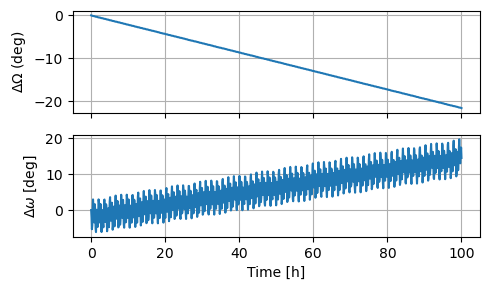

In [43]:
# Initial conditions
a_0 = 6718e3
e_0 = 0.008931
Omega_0 = 45*deg # It is important to avoid an initial value of 0
inc_0 = 51.43*deg
omega_0 = 45*deg # It is important to avoid an initial value of 0
f_0 = 0*deg
M = GM_DEFAULT / pc.constantes.G

# System creation
sim = rb.Simulation()
sim.units = 'kg', 'm', 's'
sim.add(m=M)
sim.add(m=0, a=a_0, e=e_0, inc=inc_0, Omega=Omega_0, omega=omega_0, f=f_0)

sim.additional_forces = aceleracion_no_esferico_J2
sim.force_is_velocity_dependent = True

# Simulation
deltat = 100*3600
Nt = 1000
ts = np.linspace(sim.t, sim.t + deltat, Nt)
Es = np.zeros((Nt, 5))

for i, t_step in enumerate(ts):
    sim.integrate(t_step)
    o = sim.orbits()[0]
    Es[i] = [o.a, o.e, o.inc, o.Omega, o.omega]

# Plotting
pio.renderers.default = "png"
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(5, 3))

# Difference in Omega in degrees
axes[0].plot(ts/3600, (Es[:, 3] - Omega_0) * rad)
axes[0].set_ylabel(r'$\Delta \Omega$ (deg)')
axes[0].grid(True)

# Difference in omega in degrees
axes[1].plot(ts/3600, (Es[:, 4] - omega_0) * rad)
axes[1].set_ylabel(r'$\Delta \omega$ [deg]')
axes[1].set_xlabel('Time [h]')
axes[1].grid(True)

plt.tight_layout()
plt.show()

To measure the observed rate, let us perform a linear fit:

In [44]:
dWs = (Es[:, 3] - Omega_0) * rad
pendiente_dWs, intercepto_dWs = np.polyfit(ts, dWs, 1)
print(f"Regression rate of the line of nodes (linear fit): {pendiente_dWs*86400:.4f} degrees/day")

dws = (Es[:, 4] - omega_0) * rad
pendiente_dws, intercepto_dws = np.polyfit(ts, dws, 1)
print(f"Periapsis advance rate (linear fit): {pendiente_dws*86400:.4f} degrees/day")

Regression rate of the line of nodes (linear fit): -5.1853 degrees/day
Periapsis advance rate (linear fit): 3.9312 degrees/day


This agrees almost exactly with the values reported in the book.

# Sun Position

To determine whether a satellite receives sunlight, we must first know where the Sun is at each moment relative to Earth. For this, we can use SPICE:

In [131]:
import spiceypy as spy
import os
import urllib.request

KERNEL_DIR = "kernels"
os.makedirs(KERNEL_DIR, exist_ok=True)

kernels = {
    "naif0012.tls": "https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/naif0012.tls",
    "de430.bsp":    "https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/de430.bsp",
}

for fname, url in kernels.items():
    path = os.path.join(KERNEL_DIR, fname)
    if not os.path.exists(path):
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(url, path)
    spy.furnsh(path)

print("Kernels Correctly Loaded.")

Kernels Correctly Loaded.


In [46]:
!pip install -Uq pymcel
import pymcel as pc
import spiceypy as spy
#pc.prepara_spice(verbose=False)

This is how we query the Sun's position at a given date (we will use a date close to the one provided in Example 10.7):

In [47]:
# Convert the date to ephemeris time (seconds from J2000)
et = spy.utc2et('2013-07-25 08:00:00')

# Convert seconds to Julian date
jd = spy.unitim(et, 'ET', 'JDTDB')

# Query the position of the Sun (10) relative to Earth (399)
estado, lt = spy.spkezr('10', et, 'J2000', 'NONE', '399')

# Extract the position from the state vector
r_sol = estado[:3] * 1000 # In meters

r_sol

array([-8.13275827e+10,  1.17755795e+11,  5.10495485e+10])

This position is given in the ecliptic coordinate system. We must transform it to the equatorial system, which is the one we use for Earth:

In [48]:
Mecl2equ = spy.pxform('ECLIPJ2000', 'J2000', 0)
r_sol_equ = spy.mxv(Mecl2equ, r_sol)

Once the Sun's position has been calculated, we can determine its pointing direction and distance:

In [49]:
uvec, r0 = spy.unorm(r_sol_equ)
uvec, r0/1e3

(array([-0.53525079,  0.57740413,  0.61653148]), 151942947.59763703)

To determine whether the Sun shines on a satellite, we will use the criterion from the book:

$$
\begin{aligned}
\theta & =\cos ^{-1}\left(\frac{\vec{r}_\mathrm{sol} \cdot \vec{r}_\mathrm{sat}}{r_\mathrm{sol} r_\mathrm{sat}}\right)\\
\theta_1 & =\cos ^{-1} \frac{R}{r_\mathrm{sol}}\\
\theta_2 & =\cos ^{-1} \frac{R}{r_\mathrm{sat}}\\
\end{aligned}
$$

Let us consider, for example, a satellite with these orbital elements:

In [50]:
e_0 = 0.3
a_0 = 10000e3 # m
Omega_0 = 45*deg # It is important to avoid an initial value of 0
inc_0 = 80*deg
omega_0 = 10*deg # It is important to avoid an initial value of 0
f_0 = 0*deg

Let us calculate its position with Rebound:

In [51]:
# System creation
sim = rb.Simulation()
sim.units = 'kg', 'm', 's'
sim.add(m=M)
sim.add(m=0, a=a_0, e=e_0, inc=inc_0, Omega=Omega_0, omega=omega_0, f=f_0)
r_sat = sim.particles[1].xyz
r_sat

[4725296.533447578, 5023802.831032688, 1197070.5016398402]

Let us check whether the satellite receives sunlight in this situation:

In [52]:
R = A_DEFAULT
teta = np.arccos((r_sol_equ @ r_sat) / (np.linalg.norm(r_sol_equ) * np.linalg.norm(r_sat)))
teta1 = np.arccos(R/np.linalg.norm(r_sat))
teta2 = np.arccos(R/np.linalg.norm(r_sol_equ))

teta1*rad, teta2*rad, teta*rad, (teta1 + teta2 - teta)

(np.float64(24.333525849245458),
 np.float64(89.99759488481017),
 np.float64(80.87951643312559),
 np.float64(0.5838406351255252))

Since $\theta_1 + \theta_2 - \theta > 0$, this means that the Sun is illuminating the satellite.

## Exercises:

### Exercise 1

$de/dt$:

In [53]:
e, w, q, i = sp.symbols('e omega theta i')
l_1 = sp.integrate((1 + e*sp.cos(q)) * (
    (1 + e*sp.cos(q))*sp.sin(q)*(3*sp.sin(i)**2 * sp.sin((q+w))**2 - 1)
    - ((2 + e*sp.cos(q))*sp.cos(q) + e)*sp.sin(2*(q+w))*sp.sin(i)**2) , (q, 0, 2*sp.pi))

In [54]:
l_1

3*pi*e*sin(i)**2*sin(omega)*cos(omega) - 3*pi*e*sin(i)**2*sin(2*omega)/2

In [55]:
sp.simplify(l_1)

0

Since $\sin(2w) = 2\sin(w)\cos(w)$, the terms cancel and the integral is equal to zero.

$d\Omega/dt$:

In [56]:
e, w, q = sp.symbols('e omega q')
l_Omega = sp.integrate((1 + e*sp.cos(q)) * sp.sin(w + q)**2, (q, 0, 2*sp.pi))
l_Omega

pi*sin(omega)**2 + pi*cos(omega)**2

In [57]:
sp.simplify(l_Omega)

pi

Therefore, it is equal to $\pi$

$di/dt$:

In [58]:
e, w, q = sp.symbols('e omega q')
l_i = sp.integrate((1 + e*sp.cos(q)) * sp.sin(2*(w + q)), (q, 0, 2*sp.pi))
l_i

0

$d\omega/dt$

In [59]:
e, w, q = sp.symbols('e omega q')
l_w = sp.integrate((1 + e*sp.cos(q)) * (sp.cos(q)*(1 + e*sp.cos(q))*(1 - 3*sp.sin(i)**2 * sp.sin(w + q)**2)
    - (2 + e*sp.cos(q))*sp.sin(2*(w + q))*sp.sin(i)**2 * sp.sin(q)
    + 2*e*sp.cos(i)**2 * sp.sin(w + q)**2), (q, 0, 2*sp.pi))
sp.simplify(l_w)

pi*e*(4 - 5*sin(i)**2)

### Exercise 2:

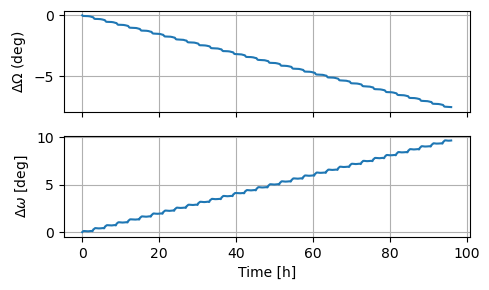

In [60]:
# Initial conditions
a_0 = 10640e3
e_0 = 0.42607
Omega_0 = 130.32*deg # It is important to avoid an initial value of 0
inc_0 = 39.687*deg
omega_0 = 42.373*deg # It is important to avoid an initial value of 0
f_0 = 52.404*deg
M = GM_DEFAULT / pc.constantes.G

# System creation
sim = rb.Simulation()
sim.units = 'kg', 'm', 's'
sim.add(m=M)
sim.add(m=0, a=a_0, e=e_0, inc=inc_0, Omega=Omega_0, omega=omega_0, f=f_0)

sim.additional_forces = aceleracion_no_esferico_J2
sim.force_is_velocity_dependent = True

# Simulation
deltat = 96*3600
Nt = 1000
ts = np.linspace(sim.t, sim.t + deltat, Nt)
Es = np.zeros((Nt, 5))

rs = np.zeros((Nt, 3))
vels = np.zeros((Nt, 3))


for i, t_step in enumerate(ts):
    sim.integrate(t_step)
    o = sim.orbits()[0]
    Es[i] = [o.a, o.e, o.inc, o.Omega, o.omega]

    rs[i] = sim.particles[1].xyz
    vels[i] = sim.particles[1].vxyz


# Plotting
pio.renderers.default = "png"
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(5, 3))

# Difference in Omega in degrees
axes[0].plot(ts/3600, (Es[:, 3] - Omega_0) * rad)
axes[0].set_ylabel(r'$\Delta \Omega$ (deg)')
axes[0].grid(True)

# Difference in omega in degrees
axes[1].plot(ts/3600, (Es[:, 4] - omega_0) * rad)
axes[1].set_ylabel(r'$\Delta \omega$ [deg]')
axes[1].set_xlabel('Time [h]')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [61]:
dWs = (Es[:, 3] - Omega_0) * rad
pendiente_dWs, intercepto_dWs = np.polyfit(ts, dWs, 1)
print(f"Regression rate of the line of nodes (linear fit): {pendiente_dWs} deg/s")

dws = (Es[:, 4] - omega_0) * rad
pendiente_dws, intercepto_dws = np.polyfit(ts, dws, 1)
print(f"Periapsis advance rate (linear fit): {pendiente_dws} deg/s")

Regression rate of the line of nodes (linear fit): -2.2070288882859874e-05 deg/s
Periapsis advance rate (linear fit): 2.8117550729935507e-05 deg/s


In [62]:
rs[-1]/1e3

array([ 9623.82092462,  4367.40125987, -8680.34533528])

In [63]:
vels[-1]/1e3

array([-3.06491498,  3.32016591,  0.64841583])

In [64]:
print(f"The position is {(rs[-1]/1e3)[0]:0f} i + {(rs[-1]/1e3)[1]:0f} j  {(rs[-1]/1e3)[2]:0f} k [km]")

The position is 9623.820925 i + 4367.401260 j  -8680.345335 k [km]


In [65]:
print(f"The velocity is {(vels[-1]/1e3)[0]:0f} i + {(vels[-1]/1e3)[1]:0f} j  {(vels[-1]/1e3)[2]:0f} k [km]")

The velocity is -3.064915 i + 3.320166 j  0.648416 k [km]


### Hinode (Solar-B)

In [66]:
mu = GM_DEFAULT
mu

398600441500000.0

In [91]:
def posicion_sol(fecha_str, t):
  # Convert the date to ephemeris time (seconds from J2000)
  et = spy.utc2et(fecha_str) - t

  # Convert seconds to Julian date
  jd = spy.unitim(et, 'ET', 'JDTDB')

  # Query the position of the Sun (10) relative to Earth (399)
  estado, lt = spy.spkezr('10', et, 'J2000', 'NONE', '399')

  # Extract the position from the state vector
  r_sol = estado[:3] * 1000 # In meters

  Mecl2equ = spy.pxform('ECLIPJ2000', 'J2000', 0)
  r_sol_equ = spy.mxv(Mecl2equ, r_sol)

  return et, r_sol_equ

In [92]:
def simulacion(parametros):
  sim = rb.Simulation()
  sim.units = 'kg', 'm', 's'
  sim.add(m=M)
  sim.add(m=0, a=parametros['a'], e=parametros['e'],
          inc=parametros['inc'], Omega=parametros['Omega'],
          omega=parametros['omega'], f=parametros['f'])

  return sim

In [93]:
def posiciones(sim, deltat, Nt):
  ts = np.linspace(-deltat, 0, Nt)
  r_sats = []
  v_sats = []
  r_sols = []

  for i, t_step in enumerate(ts):
    sim.integrate(t_step)
    r_sats.append(np.array([sim.particles[1].x,
                          sim.particles[1].y,
                          sim.particles[1].z]))
    v_sats.append(np.array([sim.particles[1].vx,
                          sim.particles[1].vy,
                          sim.particles[1].vz]))
    r_sols.append(posicion_sol(fecha_str, t_step)[1])

  return np.array(r_sats), np.array(r_sols), ts


Since this was presenting an error, Gemini corrected it to avoid division by zero:

In [94]:
def iluminado(r_sat, r_sol, R=A_DEFAULT):
  r_sat = np.asarray(r_sat)
  r_sol = np.asarray(r_sol)

  r_sat_mag = np.linalg.norm(r_sat)
  r_sol_mag = np.linalg.norm(r_sol)

  if r_sat_mag < 1e-9 or r_sol_mag < 1e-9:
      return np.nan, np.nan, np.nan, -1

  teta = np.arccos(np.dot(r_sol, r_sat) / (r_sol_mag * r_sat_mag))
  teta1 = np.arccos(R / r_sat_mag)
  teta2 = np.arccos(R / r_sol_mag)

  return teta1, teta2, teta, (teta1 + teta2 - teta)

The initial conditions are defined:

In [95]:
def anomalia_verdadera(e, M):
  f = M + 2 * e * np.sin(M)
  return f

In [96]:
!pip install -Uq sgp4
from sgp4.io import twoline2rv
from sgp4.earth_gravity import wgs84

In [97]:
def satellite(file):
  with open(file, 'r') as f:
    lines=f.readlines()
  for i in range(0,len(lines),2):
      line1=lines[i].strip()
      line2=lines[i+1].strip()
      satellite=twoline2rv(line1,line2,wgs84)

  e0 = satellite.__dict__['ecco']
  Omega0 = satellite.__dict__['nodeo']
  inc0 = satellite.__dict__['inclo']
  omega0 = satellite.__dict__['argpo']
  M0 = satellite.__dict__['mo']
  n0 = satellite.__dict__['no_kozai'] / 60
  a0 = (mu/n0**2)**(1/3)
  f0 = anomalia_verdadera(e0, M0)
  parametros = {'a': a0, 'e': e0, 'inc': inc0, 'Omega': Omega0, 'omega': omega0, 'f': f0}
  return parametros

In [98]:
%%file TLE.txt
1 29479U 06041A   25301.50656665  .00001077  00000-0  19527-3 0  9994
2 29479  98.0687 315.9951 0016450 305.8018  54.1657 14.68188019 20876

Overwriting TLE.txt


In [99]:
fecha_str = '2025-10-20 12:09:27'
deltat= 8 * 86400
Nt = 1000

The functions are called as follows:

In [100]:
parametros = satellite('TLE.txt')
parametros

{'a': 7044995.5651934855,
 'e': 0.001645,
 'inc': 1.7116217081505631,
 'Omega': 5.515154915168734,
 'omega': 5.337248268525196,
 'f': np.float64(0.9480370540295028)}

In [101]:
sim1 = simulacion(parametros)
sim1

<rebound.simulation.Simulation object at 0x1fcf3d44ea0, N=2, t=0.0>

In [102]:
r_sats, r_sols, ts = posiciones(sim1, deltat, Nt)

In [103]:
print(r_sats.shape, r_sols.shape, ts.shape)

(1000, 3) (1000, 3) (1000,)


In [104]:
print(type(r_sats))
print(r_sats)

<class 'numpy.ndarray'>
[[-4659758.61666986  4895245.97888302 -2002115.67497704]
 [-2019582.56574948  3128274.23241414 -5975166.74102971]
 [ 1674384.51612073  -271699.19157721 -6826852.51837387]
 ...
 [ 1143575.02135777   262591.10517623 -6936475.88198781]
 [ 4202531.13191092 -3134947.1412637  -4688616.63522755]
 [ 5061003.63709057 -4891075.16506039    14634.0479406 ]]


In [105]:
r_sat_ini = r_sats[0]
r_sol_ini = r_sols[0]

In [106]:
r_sol_ini

array([-1.21789369e+11, -5.82416374e+10, -6.21838907e+10])

In [107]:
R = A_DEFAULT
theta = np.arccos((r_sol_ini @ r_sat_ini) / (np.linalg.norm(r_sol_ini) * np.linalg.norm(r_sat_ini)))
theta1 = np.arccos(R/np.linalg.norm(r_sat_ini))
theta2 = np.arccos(R/np.linalg.norm(r_sol_ini))

theta1*rad, theta2*rad, theta*rad, (theta1 + theta2 - theta)

(np.float64(25.19594102175804),
 np.float64(89.9975413138827),
 np.float64(67.14598081739184),
 np.float64(0.8385870988504176))

#### Just in case, verification without functions:

In [109]:
# Convert the date to ephemeris time (seconds from J2000)
et = spy.utc2et('2025-10-20 12:09:27')

# Convert seconds to Julian date
jd = spy.unitim(et, 'ET', 'JDTDB')

# Query the position of the Sun (10) relative to Earth (399)
estado, lt = spy.spkezr('10', et, 'J2000', 'NONE', '399')


In [110]:
Mecl2equ = spy.pxform('ECLIPJ2000', 'J2000', 0)
r_sol_equ = spy.mxv(Mecl2equ, r_sol)
r_sol_equ

array([-8.13275827e+10,  8.77324853e+10,  9.36776102e+10])

In [111]:
uvec, r0 = spy.unorm(r_sol_equ)
uvec, r0/1e3

(array([-0.53525079,  0.57740413,  0.61653148]), 151942947.59763703)

In [112]:
#1 29479U 06041A   25301.50656665  .00001077  00000-0  19527-3 0  9994
#2 29479  98.0687 315.9951 0016450 305.8018  54.1657 14.68188019 20876

To create a *txt* file in Colab

In [113]:
%%file TLE1.txt
1 29479U 06041A   25301.50656665  .00001077  00000-0  19527-3 0  9994
2 29479  98.0687 315.9951 0016450 305.8018  54.1657 14.68188019 20876

Writing TLE1.txt


In [114]:
!pip install -Uq sgp4

In [115]:
from sgp4.io import twoline2rv
from sgp4.earth_gravity import wgs84
with open('TLE1.txt', 'r') as f:
    lines=f.readlines()
for i in range(0,len(lines),2):
    line1=lines[i].strip()
    line2=lines[i+1].strip()
    satellite=twoline2rv(line1,line2,wgs84)
print(satellite.__dict__)


{'error': 0, 'satnum_str': '29479', 'classification': 'U', 'intldesg': '06041A', 'epochdays': 301.50656665, 'ndot': 3.2634020909685644e-11, 'nddot': 0.0, 'bstar': 0.00019527, 'ephtype': '0', 'elnum': 999, 'inclo': 1.7116217081505631, 'nodeo': 5.515154915168734, 'ecco': 0.001645, 'argpo': 5.337248268525196, 'mo': 0.9453698066474926, 'no_kozai': 0.06406178742470765, 'revnum': ' 2087', 'epochyr': 2025, 'jdsatepoch': 2460977.00656665, 'epoch': datetime.datetime(2025, 10, 28, 12, 9, 27, 358560), 'isimp': 0, 'method': 'n', 'aycof': 0.001157868335533432, 'con41': -0.9408968972081282, 'cc1': 3.546232066959773e-10, 'cc4': 3.8225708813326794e-08, 'cc5': 5.844960516484046e-05, 'd2': 6.045835590245074e-18, 'd3': 1.5389504780543925e-25, 'd4': 4.565580207129411e-33, 'delmo': 1.0351278086559725, 'eta': 0.019770968245503128, 'argpdot': -3.840478848748007e-05, 'omgcof': 5.9252545284568694e-09, 'sinmao': 0.8107134899727085, 't': 0.0, 't2cof': 5.31934810043966e-10, 't3cof': 6.297350827699749e-18, 't4cof'

In [116]:
mu = GM_DEFAULT
mu

398600441500000.0

In [117]:
e0 = satellite.__dict__['ecco']
Omega0 = satellite.__dict__['nodeo']
inc0 = satellite.__dict__['inclo']
omega0 = satellite.__dict__['argpo']
M0 = satellite.__dict__['mo']
n0 = satellite.__dict__['no_kozai'] /60
a0 = (mu/n0**2)**(1/3)

In [118]:
e0, np.rad2deg(Omega0), np.rad2deg(inc0), np.rad2deg(omega0), np.rad2deg(M0), n0, a0

(0.001645,
 np.float64(315.9951),
 np.float64(98.0687),
 np.float64(305.8018),
 np.float64(54.1657),
 0.001067696457078461,
 7044995.5651934855)

In [119]:
def funcion_kepler(E, e, M):
  return E - e * np.sin(E) - M

In [120]:
from scipy.optimize import newton

In [121]:
E0 = newton(funcion_kepler, M0, args=(e0, M0))

In [122]:
np.rad2deg(E0)

np.float64(54.24218459964333)

In [123]:
def anomalia_verdadera(e, E):
  f = 2*np.arctan2(np.sqrt(1+e)*np.sin(E/2), np.sqrt(1-e)*np.cos(E/2))
  return f

In [124]:
np.rad2deg(M0)

np.float64(54.1657)

In [125]:
f0 = anomalia_verdadera(e0, E0)
np.rad2deg(f0), f0, e0, E0

(np.float64(54.318706018664415),
 np.float64(0.9480402654485545),
 0.001645,
 np.float64(0.9467047147383384))

In [126]:
a0, e0, inc0, Omega0, omega0, f0

(7044995.5651934855,
 0.001645,
 1.7116217081505631,
 5.515154915168734,
 5.337248268525196,
 np.float64(0.9480402654485545))

In [127]:
sim0 = rb.Simulation()
sim0.units = 'kg', 'm', 's'
sim0.add(m=M)
sim0.add(m=0, a=a0, e=e0, inc=inc0, Omega=Omega0, omega=omega0, f=f0)

In [128]:
deltat = 8 * 86400
Nt = 1000
ts = np.linspace(-deltat, 0, Nt)
Es_j2 = np.zeros((Nt, 5))

rs = np.zeros((Nt, 3))
vels = np.zeros((Nt, 3))

for i, t_step in enumerate(ts):
    sim0.integrate(t_step)
    o = sim0.orbits()[0]
    Es_j2[i] = [o.a, o.e, o.inc, o.Omega, o.omega]

    rs[i] = sim0.particles[1].xyz
    vels[i] = sim0.particles[1].vxyz


In [129]:
rs = rs[0]
rs

array([-4659751.8282564 ,  4895243.6392716 , -2002137.07120056])

In [130]:
R = A_DEFAULT
teta = np.arccos((r_sol_equ @ rs) / (np.linalg.norm(r_sol_equ) * np.linalg.norm(rs)))
teta1 = np.arccos(R/np.linalg.norm(rs))
teta2 = np.arccos(R/np.linalg.norm(r_sol_equ))

teta1*rad, teta2*rad, teta*rad, (teta1 + teta2 - teta)

(np.float64(25.19594041543062),
 np.float64(89.99759488481017),
 np.float64(54.56942312373232),
 np.float64(1.0580903635784584))